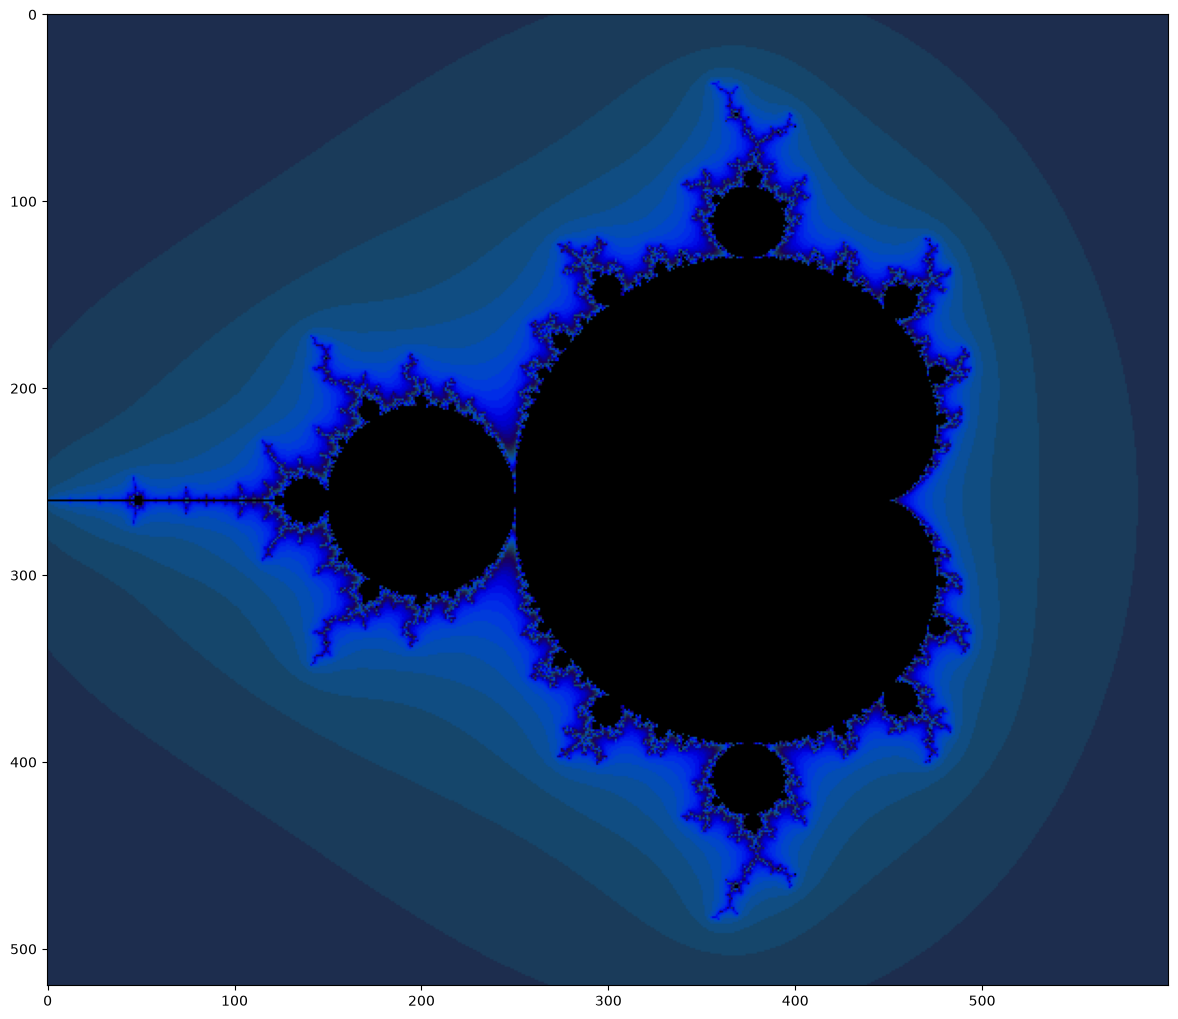

In [ ]:
# 2.1
import torch
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Y, X = np.mgrid[-1.3:1.3:0.005, -2:1:0.005]

x = torch.Tensor(X)
y = torch.Tensor(Y)
z = torch.complex(x, y)
zs = z.clone()
ns = torch.zeros_like(x)

z = z.to(device)
zs = zs.to(device)
ns = ns.to(device)

for i in range (200):
    zs_ = zs*zs + z

    not_diverged = torch.abs(zs_) < 4.0

    ns += not_diverged
    zs = zs_

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16, 10))

def processFractal(a):
    a_cyclic = (6.28*a/20.0).reshape(list(a.shape) + [1])
    img = np.concatenate([10+20*np.cos(a_cyclic),
                          30+50*np.sin(a_cyclic),
                          155-80*np.cos(a_cyclic)], 2)
    img[a==a.max()] = 0
    a = img
    a = np.uint8(np.clip(a, 0, 255))
    return a

plt.imshow(processFractal(ns.cpu().numpy()))
plt.tight_layout(pad=0)
plt.show()

Using device: cpu


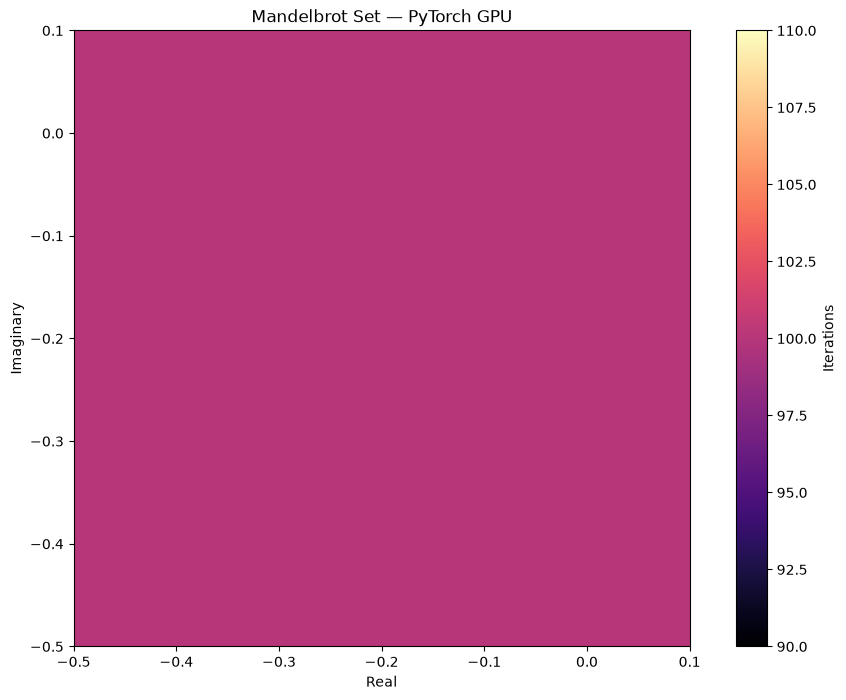

In [2]:
# 2.2
import torch
import matplotlib.pyplot as plt

# Select GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Image resolution
width = 1200
height = 800

# Mandelbrot region
x_min, x_max = -0.5, 0.1
y_min, y_max = -0.5, 0.1

# Create coordinate grid directly on the selected device
x = torch.linspace(x_min, x_max, width, device=device)
y = torch.linspace(y_min, y_max, height, device=device)

Y, X = torch.meshgrid(y, x, indexing="ij")

# Complex coordinates: c = x + iy
c = X + 1j * Y

# Initial z = 0
z = torch.zeros_like(c)

# Store the number of iterations before divergence
iterations = torch.zeros(c.shape, device=device)

# Mandelbrot iteration
max_iterations = 100

for i in range(max_iterations):
    # z = z^2 + c
    z = z * z + c

    # Points that have escaped
    escaped = torch.abs(z) > 2

    # Record the iteration when points escape
    iterations[escaped & (iterations == 0)] = i + 1

# Points that never escaped are inside the Mandelbrot set
iterations[iterations == 0] = max_iterations

# Move result back to CPU for Matplotlib
image = iterations.cpu().numpy()

# Plot
plt.figure(figsize=(12, 8))
plt.imshow(
    image,
    extent=[x_min, x_max, y_min, y_max],
    origin="lower",
    cmap="magma"
)

plt.colorbar(label="Iterations")
plt.title("Mandelbrot Set — PyTorch GPU")
plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.show()

### 6. Generate Mandelbrot set on GPU
**Prompt:** "Write PyTorch code to compute the Mandelbrot set on GPU using 200 iterations and plot it with a colour map."

**Result:** Worked first try, correctly vectorized (no per-pixel Python loop — the whole `z = z*z + c` update runs as a single tensor operation across the grid each iteration). Used escape radius 2 (`torch.abs(z) > 2`), versus the lab sheet's own code which effectively uses radius 4 — both are valid divergence thresholds; radius 2 is the more standard textbook value. Used Matplotlib's built-in `magma` colormap directly on the raw iteration counts, versus the lab sheet's custom cyclic RGB colouring function — a different visual style applied to the same, correct underlying iteration data. Confirmed device selection correctly falls back to CPU on my machine (no CUDA GPU available), consistent with the tutor's guidance that Demo 1 does not require GPU/HPC access.

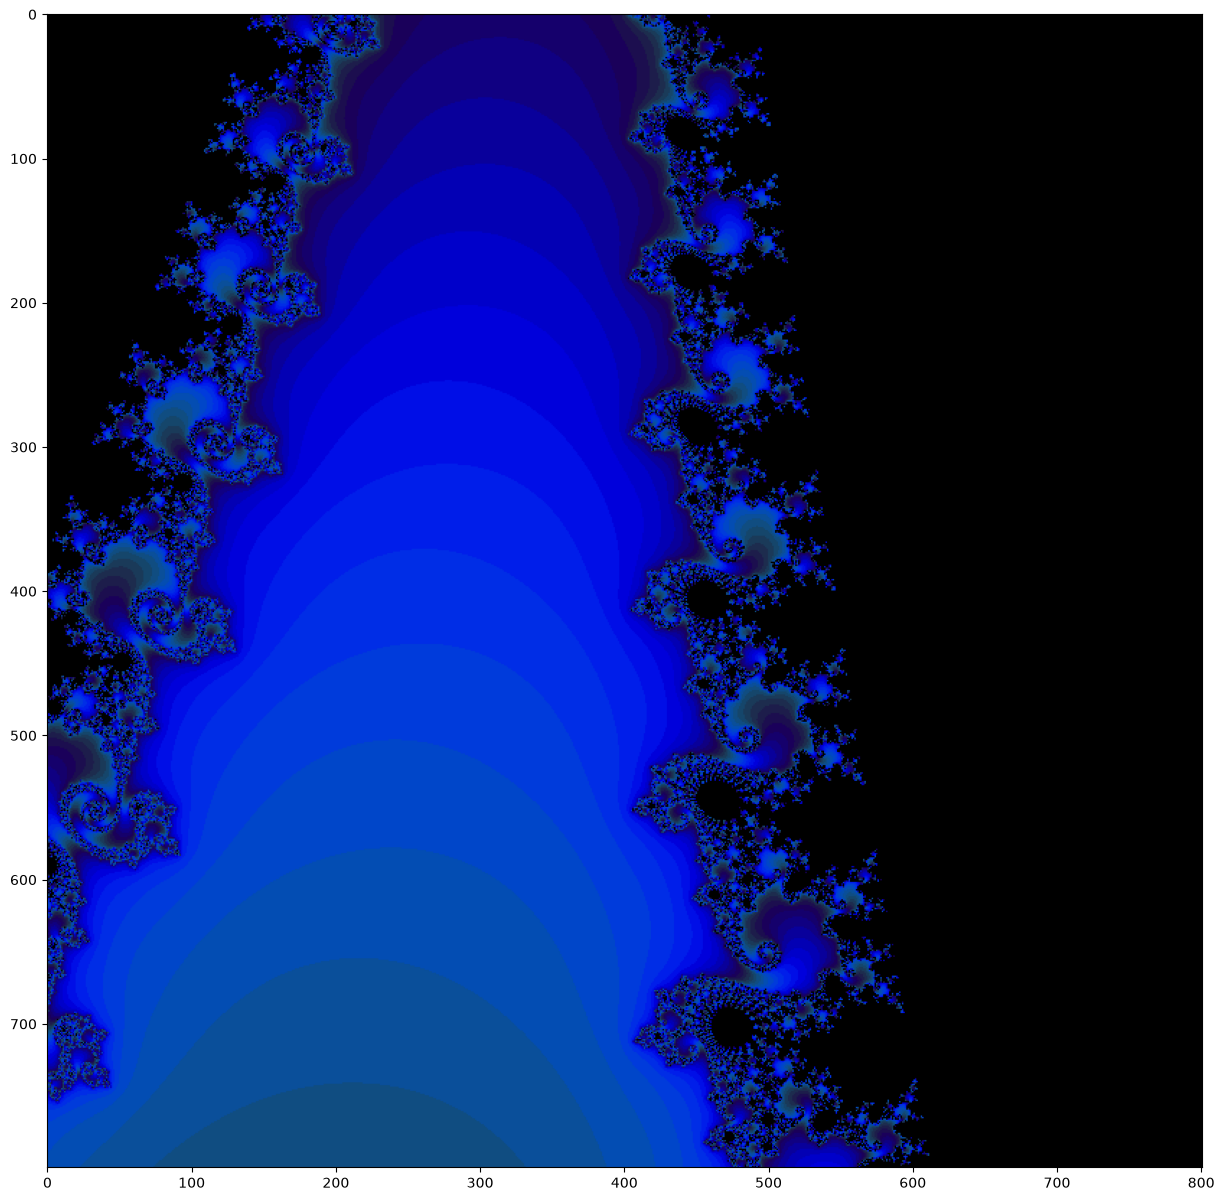

In [ ]:
# 2.3 (zoom region — seahorse valley)
import torch
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Zoom into the seahorse valley, just above the cardioid/bulb cusp
Y, X = np.mgrid[0.08:0.12:0.00005, -0.77:-0.73:0.00005]

x = torch.Tensor(X)
y = torch.Tensor(Y)
z = torch.complex(x, y)
zs = z.clone()
ns = torch.zeros_like(x)

z = z.to(device)
zs = zs.to(device)
ns = ns.to(device)

for i in range(200):
    zs_ = zs*zs + z
    not_diverged = torch.abs(zs_) < 4.0
    ns += not_diverged
    zs = zs_

import matplotlib.pyplot as plt

def processFractal(a):
    a_cyclic = (6.28*a/20.0).reshape(list(a.shape) + [1])
    img = np.concatenate([10+20*np.cos(a_cyclic),
                          30+50*np.sin(a_cyclic),
                          155-80*np.cos(a_cyclic)], 2)
    img[a==a.max()] = 0
    a = img
    a = np.uint8(np.clip(a, 0, 255))
    return a

plt.figure(figsize=(12, 12))
plt.imshow(processFractal(ns.cpu().numpy()))
plt.tight_layout(pad=0)
plt.show()

### High-resolution zoom
**Not AI-generated — self-directed debugging.** My first attempt zoomed into a region (real −0.75 to −0.65, imaginary −0.05 to 0.05) that turned out to be almost entirely inside the Mandelbrot set's main cardioid, producing an almost entirely black image. I diagnosed this myself: the fractal's detailed structure only exists at the boundary between convergence and divergence, not in the solid interior. Re-selected a boundary region (the "seahorse valley," real −0.77 to −0.73, imaginary 0.08 to 0.12) with a much finer grid step (0.00005), which produced the expected dense spiral/filament detail.

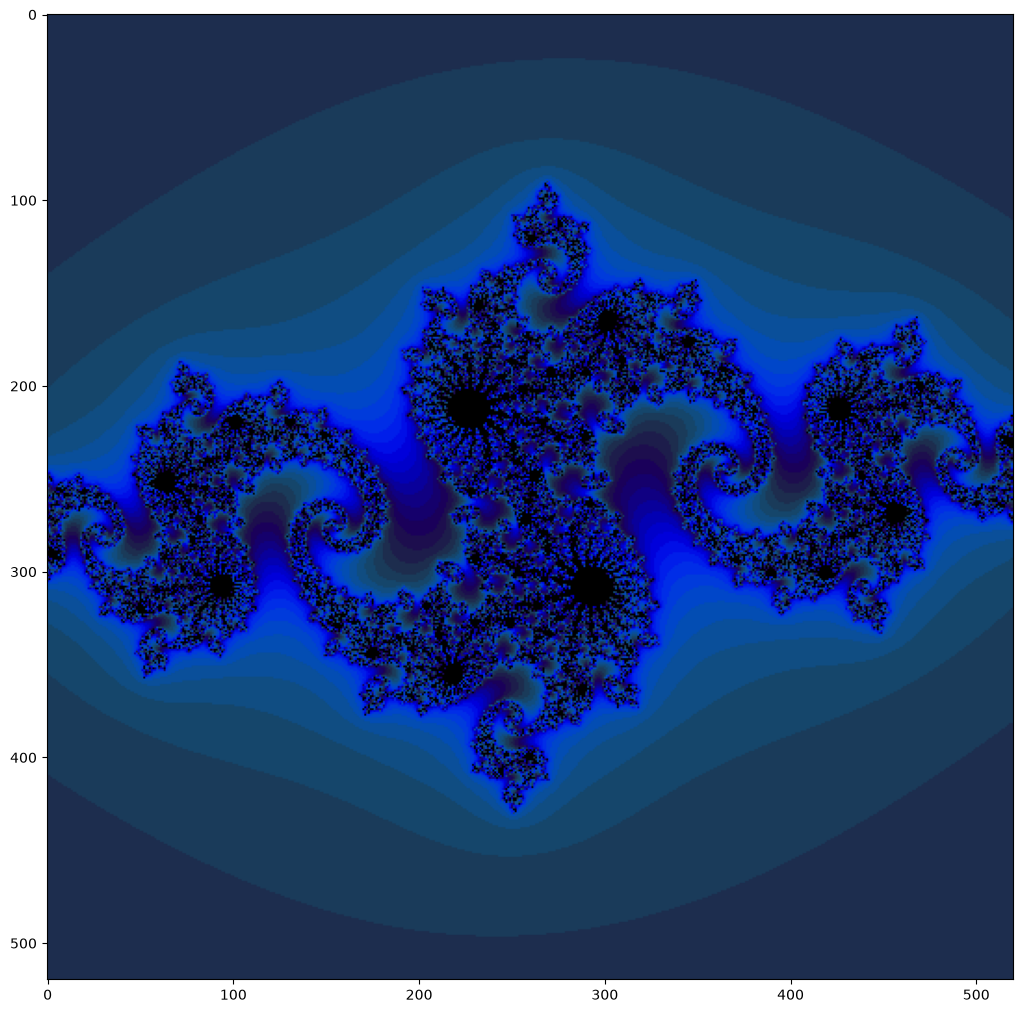

In [ ]:
# 2.3 (Julia set)
import numpy as np
import torch
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Y, X = np.mgrid[-1.3:1.3:0.005, -1.3:1.3:0.005]
x = torch.Tensor(X)
y = torch.Tensor(Y)
z0 = torch.complex(x, y).to(device)     # z0 varies per pixel now
zs = z0.clone()
ns = torch.zeros_like(x).to(device)

c = torch.complex(torch.tensor(-0.8), torch.tensor(0.156)).to(device)  # fixed constant search from https://vanderbei.princeton.edu/my_julia.html
# c = torch.complex(torch.tensor(-0.44), torch.tensor(0.58)).to(device) 
# c = torch.complex(torch.tensor(0.28), torch.tensor(0.01)).to(device)
# c = torch.complex(torch.tensor(-0.70176), torch.tensor(-0.3842)).to(device)  

for i in range(200):
    zs_ = zs * zs + c
    not_diverged = torch.abs(zs_) < 4.0
    ns += not_diverged
    zs = zs_

def processFractal(a):
    a_cyclic = (6.28*a/20.0).reshape(list(a.shape) + [1])
    img = np.concatenate([10+20*np.cos(a_cyclic),
                          30+50*np.sin(a_cyclic),
                          155-80*np.cos(a_cyclic)], 2)
    img[a==a.max()] = 0
    a = img
    a = np.uint8(np.clip(a, 0, 255))
    return a

plt.figure(figsize=(10, 10))
plt.imshow(processFractal(ns.cpu().numpy()))
plt.tight_layout(pad=0)
plt.show()

### Julia set
**Not AI-generated.** Converted my own Mandelbrot code to a Julia set myself by swapping which quantity is fixed and which varies per pixel: in the Mandelbrot set, `c` varies per pixel and `z₀ = 0` is fixed; in a Julia set, `c` is a single fixed constant and `z₀` varies per pixel (the coordinate grid itself becomes the starting point). Tried several classic constants search from https://vanderbei.princeton.edu/my_julia.html (`-0.8+0.156j`, `-0.4+0.6j`, `0.285+0.01j`, `-0.70176-0.3842j`, `-0.999+0.3j`) and selected `-0.8+0.156j` for the final result, which produced a clean dendrite-like Julia set shape.